Detected Targets:
--------------------------------------------------
Target 1
  Center       : (682, 866)
  Axes (min/maj): (28.2, 30.2)
  Aspect Ratio : 1.07
  Circularity  : 0.885
  BBox TL-BR   : (662,845) -> (703,888)

Target 2
  Center       : (589, 866)
  Axes (min/maj): (26.3, 29.8)
  Aspect Ratio : 1.133
  Circularity  : 0.884
  BBox TL-BR   : (570,845) -> (609,888)

Target 3
  Center       : (748, 858)
  Axes (min/maj): (10.1, 27.5)
  Aspect Ratio : 2.739
  Circularity  : 0.611
  BBox TL-BR   : (737,838) -> (760,879)

Target 4
  Center       : (682, 622)
  Axes (min/maj): (28.2, 30.2)
  Aspect Ratio : 1.07
  Circularity  : 0.885
  BBox TL-BR   : (662,601) -> (703,644)

Target 5
  Center       : (589, 622)
  Axes (min/maj): (26.3, 29.8)
  Aspect Ratio : 1.133
  Circularity  : 0.884
  BBox TL-BR   : (570,601) -> (609,644)

Target 6
  Center       : (748, 619)
  Axes (min/maj): (10.1, 27.5)
  Aspect Ratio : 2.739
  Circularity  : 0.611
  BBox TL-BR   : (737,599) -> (760,640)


To

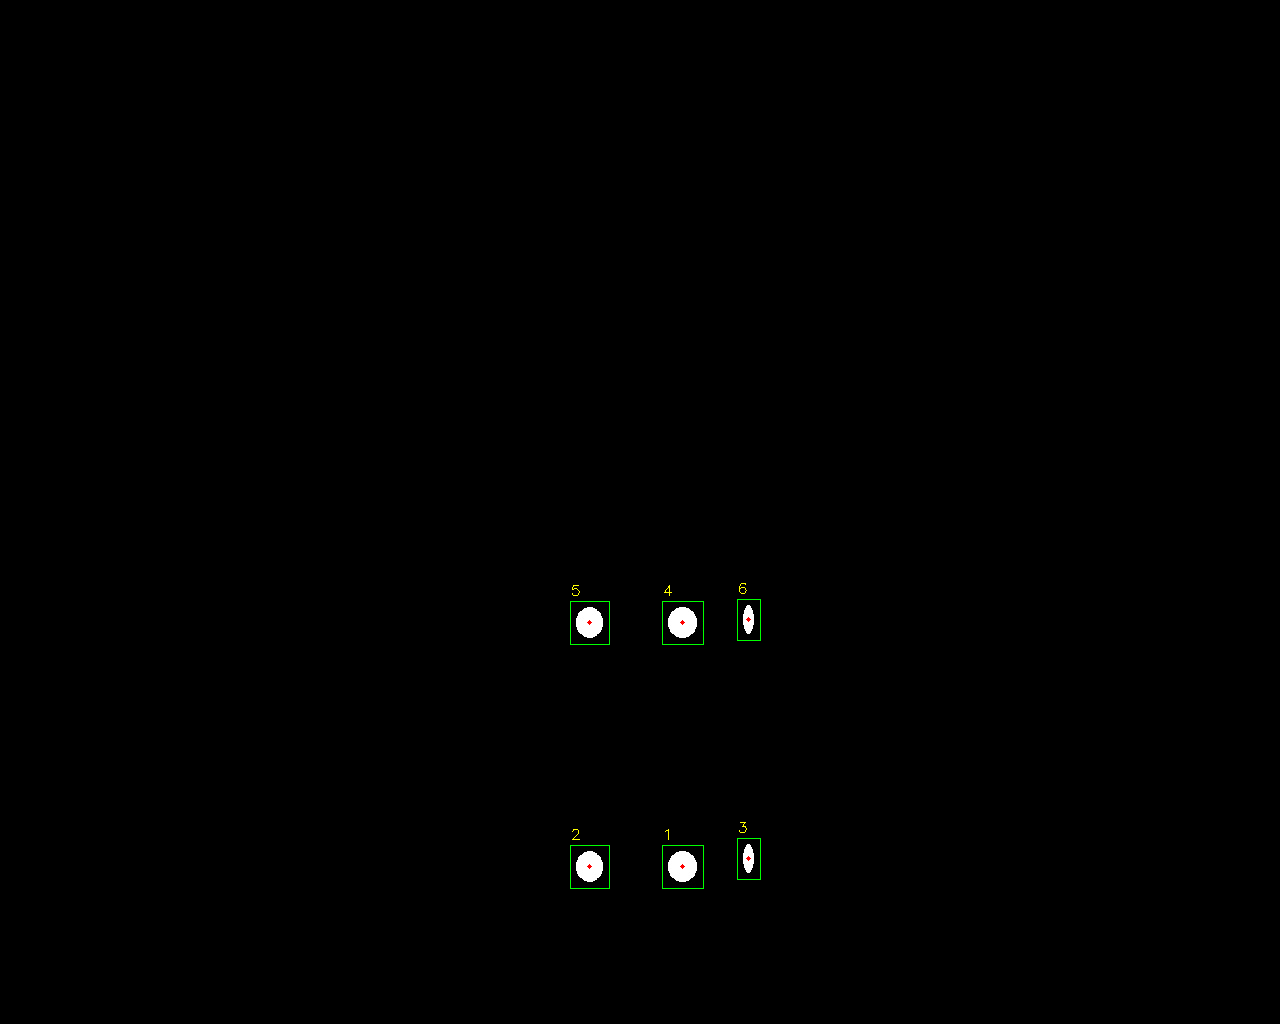

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/frame_0004.jpg", cv2.IMREAD_GRAYSCALE)
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# ── Step 1: Isolate the rocket body (dark region) ───────────────
_, dark_mask = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY_INV)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
dark_closed = cv2.morphologyEx(dark_mask, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(dark_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rect_contour = max(contours, key=cv2.contourArea)

body_mask = np.zeros_like(img)
cv2.drawContours(body_mask, [rect_contour], -1, 255, thickness=cv2.FILLED)

# ── Step 2: Find bright pixels ONLY inside the rocket body ──────
_, bright_mask = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)
circles_only = cv2.bitwise_and(bright_mask, body_mask)

# FIX 1: Shrink the kernel to (3,3). A (7,7) kernel will completely erase thin ellipses.
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
circles_only = cv2.morphologyEx(circles_only, cv2.MORPH_OPEN, kernel_open)

# ── Step 3: Find contours of individual circles ─────────────────
contours, _ = cv2.findContours(circles_only, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ── Step 4: Filter, fit ellipses, and draw ──────────────────────
print("Detected Targets:")
print("-" * 50)

obj_id = 0
margin = -6  # inset margin for bounding box

for cnt in contours:
    area = cv2.contourArea(cnt)

    # FIX 2: Lower the area threshold. Highly compressed targets have much smaller pixel areas.
    if area < 50:
        continue
    if len(cnt) < 5:
        continue

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue

    circularity = 4 * np.pi * area / (perimeter ** 2)
    # FIX 3: Lower circularity requirement. Thin ellipses naturally have very low circularity scores.
    if circularity < 0.10:
        continue

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    if hull_area == 0:
        continue
    solidity = area / hull_area
    if solidity < 0.80: # Solidity is still a good check; ellipses should still be solid/convex
        continue

    (cx, cy), (d1, d2), angle = cv2.fitEllipse(cnt)
    major_axis = max(d1, d2)
    minor_axis = min(d1, d2)

    if minor_axis == 0:
        continue

    aspect_ratio = major_axis / minor_axis
    # FIX 4: Increase aspect ratio tolerance. A cylinder curve creates highly stretched projections.
    if aspect_ratio > 8.0:
        continue

    obj_id += 1
    x, y, w, h = cv2.boundingRect(cnt)

    # Inset bounding box
    x1, y1 = x + margin, y + margin
    x2, y2 = x + w - margin, y + h - margin

    print(f"Target {obj_id}")
    print(f"  Center       : ({int(cx)}, {int(cy)})")
    print(f"  Axes (min/maj): ({round(minor_axis,1)}, {round(major_axis,1)})")
    print(f"  Aspect Ratio : {round(aspect_ratio, 3)}")
    print(f"  Circularity  : {round(circularity, 3)}")
    print(f"  BBox TL-BR   : ({x1},{y1}) -> ({x2},{y2})")
    print()

    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 1)
    cv2.circle(output, (int(cx), int(cy)), 2, (0, 0, 255), -1)
    cv2.putText(output, str(obj_id), (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

print(f"\nTotal targets detected: {obj_id}")
cv2.imwrite("detected_output.png", output)
cv2_imshow(output)

ID   | Observed X | Observed Y | Δx Shift   | Δy Shift   | Corrected X | Corrected Y
-------------------------------------------------------------------------------------
1    | 682.000    | 866.026    | -0.0322    | 0.0018     | 682.032    | 866.024   
2    | 588.998    | 866.038    | 0.0399     | 0.0030     | 588.958    | 866.035   
3    | 748.000    | 858.000    | -0.0295    | 0.0117     | 748.030    | 857.988   
4    | 682.000    | 622.026    | -0.0322    | 0.0005     | 682.032    | 622.026   
5    | 588.998    | 622.038    | 0.0399     | 0.0009     | 588.958    | 622.037   
6    | 748.000    | 619.000    | -0.0295    | 0.0036     | 748.030    | 618.996   


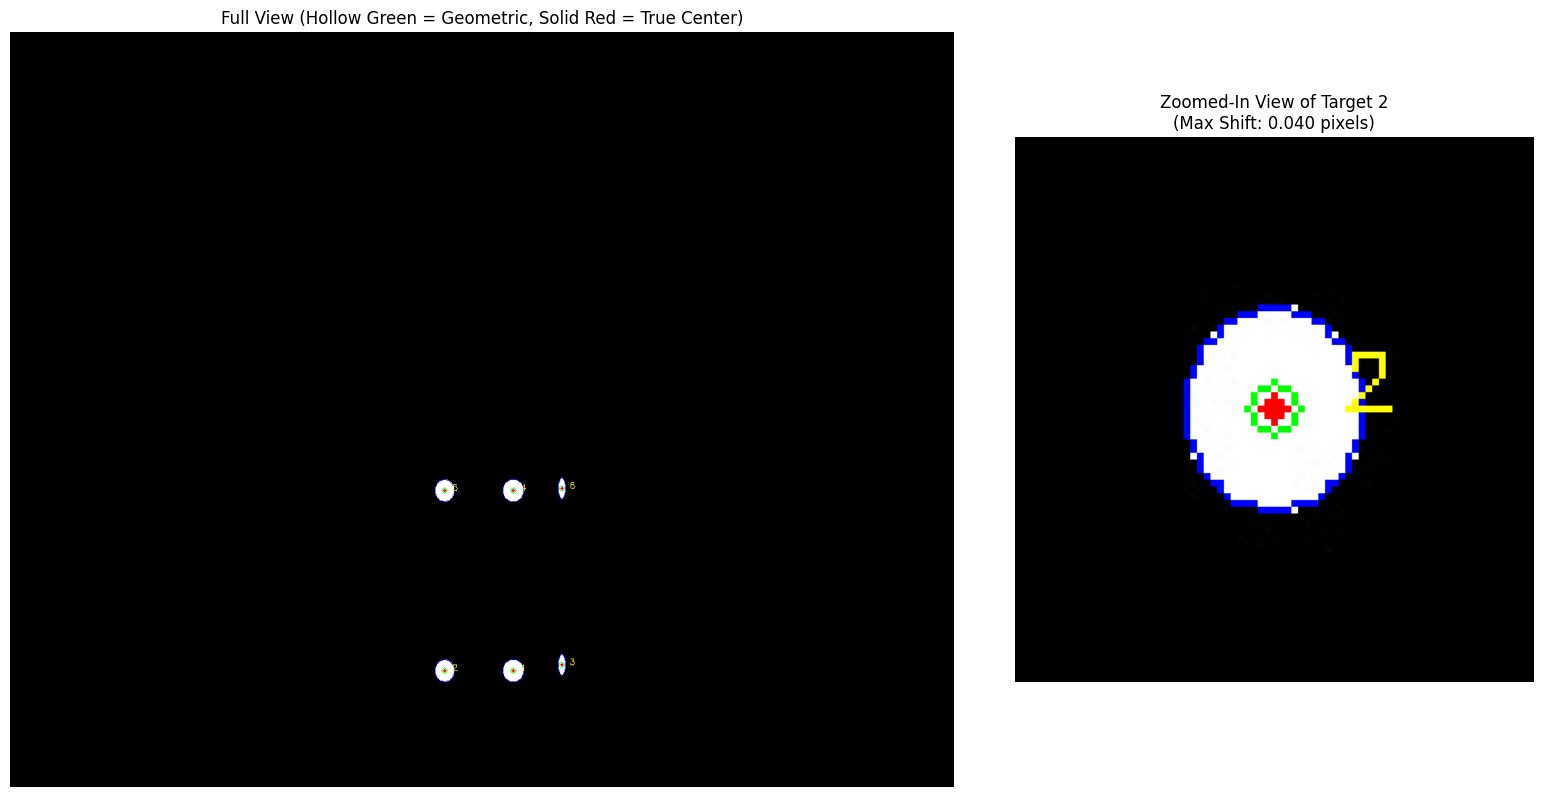

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Camera Parameters (Matched to your synthetic dataset) ---
f_px = 2500.0        # Synthetic telephoto focal length
cx = 1280.0 / 2.0
cy = 1024.0 / 2.0

camera_matrix = np.array([
    [f_px, 0, cx],
    [0, f_px, cy],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.zeros((4, 1))

# --- 2. Physical Setup ---
ROCKET_Z = 4.0       # Synthetic dataset distance
TARGET_RADIUS = 0.025 # 2.5cm targets

# --- 3. Matsuoka Eccentricity Function ---
def calculate_matsuoka_deviation(center_3d, normal_3d, radius_m, cam_matrix, dist):
    # Project the exact 3D true center
    p_c, _ = cv2.projectPoints(center_3d.reshape(1, 1, 3), np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)
    xc, yc = p_c[0][0]

    # Generate 3D perimeter points to form the physical circle
    normal_3d = normal_3d / np.linalg.norm(normal_3d)
    v_arbitrary = np.array([1.0, 0.0, 0.0]) if abs(normal_3d[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(v_arbitrary, normal_3d)
    u = u / np.linalg.norm(u)
    v = np.cross(normal_3d, u)

    theta = np.linspace(0, 2 * np.pi, 360)
    perimeter_3d = center_3d + radius_m * (np.outer(np.cos(theta), u) + np.outer(np.sin(theta), v))

    # Project the 3D perimeter to 2D and fit an ellipse to find the geometric center
    perimeter_2d, _ = cv2.projectPoints(perimeter_3d.reshape(-1, 1, 3).astype(np.float32),
                                        np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)

    ellipse = cv2.fitEllipse(perimeter_2d)
    (xE, yE), axes, angle = ellipse

    return (xE - xc), (yE - yc)

# --- 4. Main Processing Pipeline ---
img_path = "/content/frame_0004.jpg"
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
output_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

_, thresh = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"{'ID':<4} | {'Observed X':<10} | {'Observed Y':<10} | {'Δx Shift':<10} | {'Δy Shift':<10} | {'Corrected X':<10} | {'Corrected Y':<10}")
print("-" * 85)

target_id = 0
crop_img = None
max_deviation = -1.0
zoomed_target_id = -1

for cnt in contours:
    if len(cnt) < 5 or cv2.contourArea(cnt) < 20:
        continue

    # 1. Get Geometric Center and Aspect Ratio
    ellipse = cv2.fitEllipse(cnt)
    (xE, yE), (minor, major), _ = ellipse

    if major == 0: continue

    # 2. DYNAMIC NORMAL CALCULATION
    # Calculate the exact 3D tilt of the target based on how squashed the ellipse is
    cos_phi = min(1.0, max(0.0, minor / major))
    phi = np.arccos(cos_phi)

    # Determine if it's on the left or right side of the rocket cylinder
    tilt_x = np.sin(phi) if xE > cx else -np.sin(phi)

    # Construct the surface normal pointing towards the camera
    normal_vector = np.array([tilt_x, 0.0, -cos_phi])

    # 3. Calculate 3D Ray
    X_dist = ((xE - cx) * ROCKET_Z) / f_px
    Y_dist = ((yE - cy) * ROCKET_Z) / f_px
    rough_3D_center = np.array([X_dist, Y_dist, ROCKET_Z])

    # 4. Apply Correction
    dx, dy = calculate_matsuoka_deviation(rough_3D_center, normal_vector, TARGET_RADIUS, camera_matrix, dist_coeffs)

    true_x = xE - dx
    true_y = yE - dy

    target_id += 1
    print(f"{target_id:<4} | {xE:<10.3f} | {yE:<10.3f} | {dx:<10.4f} | {dy:<10.4f} | {true_x:<10.3f} | {true_y:<10.3f}")

    # --- Draw Both Centers ---
    old_center_int = (int(round(xE)), int(round(yE)))
    new_center_int = (int(round(true_x)), int(round(true_y)))

    cv2.ellipse(output_img, ellipse, (255, 0, 0), 1)
    cv2.line(output_img, old_center_int, new_center_int, (255, 255, 255), 1)

    # Draw Old (Geometric) Center in Green as a HOLLOW circle
    cv2.circle(output_img, old_center_int, 4, (0, 255, 0), 1)
    # Draw New (Corrected True) Center in Red as a SOLID dot
    cv2.circle(output_img, new_center_int, 2, (0, 0, 255), -1)

    cv2.putText(output_img, f"{target_id}", (old_center_int[0] + 10, old_center_int[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

    # DYNAMIC TRACKING: Find the target with the highest Eccentricity Error
    total_shift = np.sqrt(dx**2 + dy**2)
    if total_shift > max_deviation:
        max_deviation = total_shift
        zoomed_target_id = target_id

        x, y, w, h = cv2.boundingRect(cnt)
        pad = 25
        crop_img = output_img[max(0, y-pad):min(1024, y+h+pad), max(0, x-pad):min(1280, x+w+pad)].copy()

# --- 5. Display ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

ax1.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
ax1.set_title("Full View (Hollow Green = Geometric, Solid Red = True Center)")
ax1.axis("off")

if crop_img is not None:
    # Resize crop_img to be larger for better viewing
    crop_img_large = cv2.resize(crop_img, (0,0), fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
    ax2.imshow(cv2.cvtColor(crop_img_large, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Zoomed-In View of Target {zoomed_target_id}\n(Max Shift: {max_deviation:.3f} pixels)")
    ax2.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
left_img_path = '/content/frame_0025_L.jpg'
right_img_path = '/content/frame_0025_R.jpg'

Target ID  | 3D X (m)     | 3D Y (m)     | 3D Z Depth (m) 
------------------------------------------------------------
Target 1   | -2.6022      | 6.0802       | 79.3665        
Target 2   | -0.5101      | 6.0809       | 79.3665        
Target 3   | 1.5759       | 6.0795       | 79.3276        
Target 4   | -2.6019      | 8.4444       | 79.3664        
Target 5   | -0.5090      | 8.4453       | 79.3664        
Target 6   | 1.5749       | 8.4546       | 79.4230        
Target 7   | -2.6059      | 10.8041      | 79.3665        
Target 8   | -0.5127      | 10.8047      | 79.3658        
Target 9   | 1.5700       | 10.8127      | 79.4226        
Target 10  | -2.6047      | 13.1573      | 79.3665        
Target 11  | -0.5120      | 13.1579      | 79.3665        
Target 12  | 1.5742       | 13.1591      | 79.3626        
Target 13  | -2.6022      | 15.5088      | 79.3665        
Target 14  | -0.5090      | 15.5093      | 79.3665        
Target 15  | 1.5759       | 15.5035      | 79.3276    

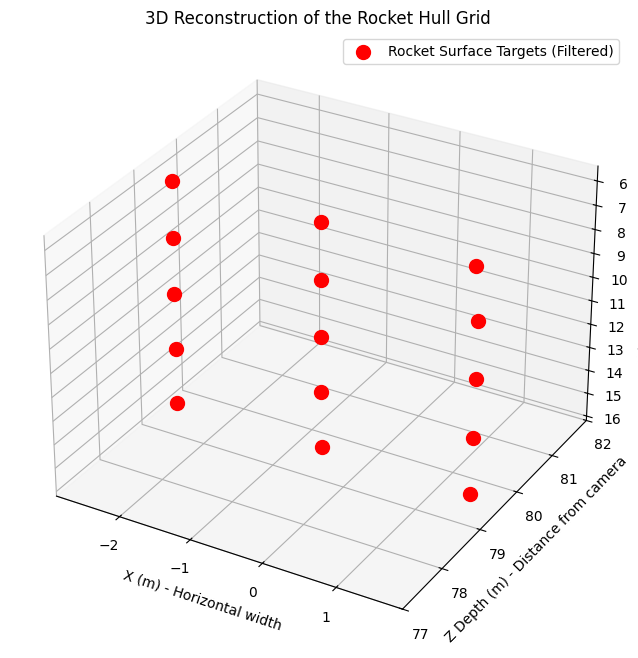

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. Camera & Rig Parameters ---
f_px = 2500.0
cx = 1280.0 / 2.0
cy = 1024.0 / 2.0

camera_matrix = np.array([
    [f_px, 0, cx],
    [0, f_px, cy],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.zeros((4, 1))

# Stereo Setup
BASELINE = 2.0
ROCKET_Z_ESTIMATE = 4.0
TARGET_RADIUS = 0.025

# Projection matrices for Triangulation
P1 = camera_matrix @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = camera_matrix @ np.hstack((np.eye(3), np.array([[-BASELINE], [0], [0]])))

# --- 2. Matsuoka Eccentricity Correction ---
def calculate_matsuoka_deviation(center_3d, normal_3d, radius_m, cam_matrix, dist):
    p_c, _ = cv2.projectPoints(center_3d.reshape(1, 1, 3), np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)
    xc, yc = p_c[0][0]

    normal_3d = normal_3d / (np.linalg.norm(normal_3d) + 1e-6)
    v_arbitrary = np.array([1.0, 0.0, 0.0]) if abs(normal_3d[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(v_arbitrary, normal_3d)
    u = u / (np.linalg.norm(u) + 1e-6)
    v = np.cross(normal_3d, u)

    theta = np.linspace(0, 2 * np.pi, 36)
    perimeter_3d = center_3d + radius_m * (np.outer(np.cos(theta), u) + np.outer(np.sin(theta), v))

    perimeter_2d, _ = cv2.projectPoints(perimeter_3d.reshape(-1, 1, 3).astype(np.float32),
                                        np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)

    ellipse = cv2.fitEllipse(perimeter_2d)
    (xE, yE), axes, angle = ellipse

    return (xE - xc), (yE - yc)

# --- 3. Target Extraction Pipeline ---
def get_corrected_targets(img_path):
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if image is None: return []

    _, thresh = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    targets = []
    for cnt in contours:
        if len(cnt) < 5 or cv2.contourArea(cnt) < 20: continue

        ellipse = cv2.fitEllipse(cnt)
        (xE, yE), (minor, major), _ = ellipse
        if major == 0: continue

        cos_phi = min(1.0, max(0.0, minor / major))
        phi = np.arccos(cos_phi)
        tilt_x = np.sin(phi) if xE > cx else -np.sin(phi)
        normal_vector = np.array([tilt_x, 0.0, -cos_phi])

        X_dist = ((xE - cx) * ROCKET_Z_ESTIMATE) / f_px
        Y_dist = ((yE - cy) * ROCKET_Z_ESTIMATE) / f_px
        rough_3D_center = np.array([X_dist, Y_dist, ROCKET_Z_ESTIMATE])

        dx, dy = calculate_matsuoka_deviation(rough_3D_center, normal_vector, TARGET_RADIUS, camera_matrix, dist_coeffs)

        targets.append({'x': xE - dx, 'y': yE - dy, 'geometric_x': xE, 'geometric_y': yE})
    return targets

# --- 4. Robust Grid Matching ---
def match_grid_targets(targets_L, targets_R, y_tol=30):
    def group_into_rows(targs):
        if not targs: return []
        targs_sorted = sorted(targs, key=lambda t: t['geometric_y'])
        rows, curr = [], [targs_sorted[0]]
        for t in targs_sorted[1:]:
            if abs(t['geometric_y'] - curr[-1]['geometric_y']) < y_tol:
                curr.append(t)
            else:
                rows.append(sorted(curr, key=lambda x: x['geometric_x']))
                curr = [t]
        rows.append(sorted(curr, key=lambda x: x['geometric_x']))
        return rows

    rows_L = group_into_rows(targets_L)
    rows_R = group_into_rows(targets_R)

    match_L, match_R = [], []
    for rL, rR in zip(rows_L, rows_R):
        for i in range(min(len(rL), len(rR))):
            match_L.append(rL[i])
            match_R.append(rR[i])
    return match_L, match_R


# --- 5. Triangulation Execution ---
left_img_path = "frame_0015_L.jpg"
right_img_path = "frame_0015_R.jpg"

targets_L = get_corrected_targets(left_img_path)
targets_R = get_corrected_targets(right_img_path)

matched_L, matched_R = match_grid_targets(targets_L, targets_R)

if not matched_L:
    print("Error: No matching targets found.")
else:
    pts_L_arr = np.array([[t['x'], t['y']] for t in matched_L], dtype=np.float32).T
    pts_R_arr = np.array([[t['x'], t['y']] for t in matched_R], dtype=np.float32).T

    mean_disp = np.mean(pts_L_arr[0, :] - pts_R_arr[0, :])
    if mean_disp < 0:
        pts_L_arr, pts_R_arr = pts_R_arr, pts_L_arr

    points_4D = cv2.triangulatePoints(P1, P2, pts_L_arr, pts_R_arr)
    points_3D = points_4D[:3, :] / points_4D[3, :]

    # --- 6. Explicitly Remove the Worst Outlier ---
    # Find the index of the point with the maximum Z-depth (the one in the far back)
    outlier_idx = np.argmax(points_3D[2, :])

    # Explicitly delete that specific column/point from the array
    points_3D_filtered = np.delete(points_3D, outlier_idx, axis=1)

    # --- 7. Output Data ---
    print(f"{'Target ID':<10} | {'3D X (m)':<12} | {'3D Y (m)':<12} | {'3D Z Depth (m)':<15}")
    print("-" * 60)

    for i in range(points_3D_filtered.shape[1]):
        x, y, z = points_3D_filtered[:, i]
        print(f"Target {i+1:<3} | {x:<12.4f} | {y:<12.4f} | {z:<15.4f}")

    print(f"\nExplicitly removed point at index {outlier_idx}.")

    # --- 8. 3D Visualization ---
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xs, ys, zs = points_3D_filtered[0, :], points_3D_filtered[1, :], points_3D_filtered[2, :]

    ax.scatter(xs, zs, ys, c='red', marker='o', s=100, depthshade=False, label='Rocket Surface Targets (Filtered)')

    ax.set_title("3D Reconstruction of the Rocket Hull Grid")
    ax.set_xlabel("X (m) - Horizontal width")
    ax.set_ylabel("Z Depth (m) - Distance from camera")
    ax.set_zlabel("Y (m) - Vertical height")
    ax.invert_zaxis()

    # --- NEW: Force axes to steps of 1 ---
    # Force the Z Depth (plotted on the figure's Y-axis) to steps of 1
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # Pad the Z Depth limits so it doesn't just show a single tick
    z_min, z_max = min(zs), max(zs)
    ax.set_ylim(np.floor(z_min) - 2, np.ceil(z_max) + 2)

    # Optional: Force the Vertical Height (plotted on the figure's Z-axis) to steps of 1 as well
    ax.zaxis.set_major_locator(ticker.MultipleLocator(1))
    # -------------------------------------

    ax.legend()
    plt.show()


Processing Stereo Pair...
Extracted 18 valid targets from /content/frame_0025_L.jpg
Extracted 18 valid targets from /content/frame_0025_R.jpg

Target ID  | 3D X (m)     | 3D Y (m)     | 3D Z Depth (m) 
------------------------------------------------------------
Target 1   | -1.5640      | 4.0938       | 80.2537        
Target 2   | 0.4360       | 4.1036       | 80.4501        
Target 3   | 2.4367       | 4.0942       | 80.2581        
Target 4   | -1.5607      | 1.8388       | 80.2606        
Target 5   | 0.4392       | 1.8424       | 80.4184        
Target 6   | 2.4384       | 1.8366       | 80.1617        
Target 7   | -1.5693      | -0.4243      | 80.3215        
Target 8   | 0.4337       | -0.4244      | 80.3880        
Target 9   | 2.4332       | -0.4228      | 80.1708        
Target 10  | -1.5621      | -2.6784      | 80.1901        
Target 11  | 0.4360       | -2.6871      | 80.4457        
Target 12  | 2.4364       | -2.6782      | 80.1809        
Target 13  | -1.5652      | 

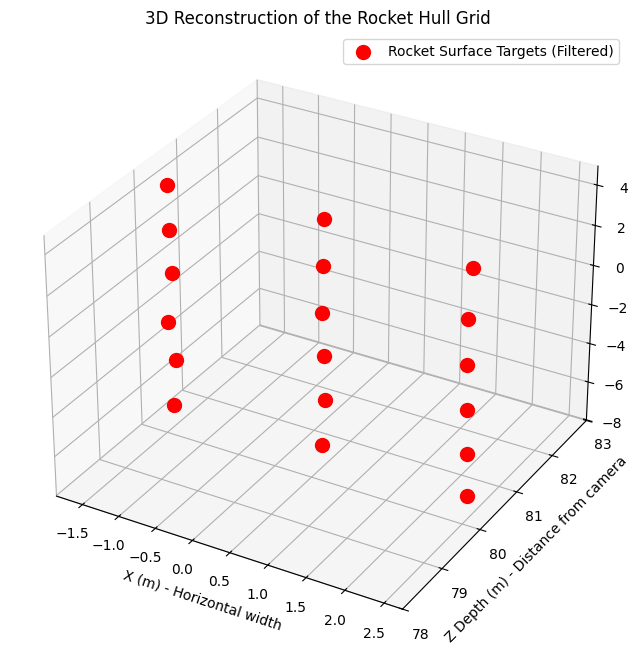

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. Camera & Rig Parameters ---
f_px = 2500.0
cx = 1280.0 / 2.0
cy = 1024.0 / 2.0

camera_matrix = np.array([
    [f_px, 0, cx],
    [0, f_px, cy],
    [0, 0, 1]
], dtype=np.float32)

dist_coeffs = np.zeros((4, 1))

BASELINE = 2.0
ROCKET_Z_ESTIMATE = 4.0
TARGET_RADIUS = 0.025

P1 = camera_matrix @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = camera_matrix @ np.hstack((np.eye(3), np.array([[-BASELINE], [0], [0]])))

# --- 2. Matsuoka Eccentricity Correction ---
def calculate_matsuoka_deviation(center_3d, normal_3d, radius_m, cam_matrix, dist):
    p_c, _ = cv2.projectPoints(center_3d.reshape(1, 1, 3), np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)
    xc, yc = p_c[0][0]

    normal_3d = normal_3d / (np.linalg.norm(normal_3d) + 1e-6)
    v_arbitrary = np.array([1.0, 0.0, 0.0]) if abs(normal_3d[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(v_arbitrary, normal_3d)
    u = u / (np.linalg.norm(u) + 1e-6)
    v = np.cross(normal_3d, u)

    theta = np.linspace(0, 2 * np.pi, 36)
    perimeter_3d = center_3d + radius_m * (np.outer(np.cos(theta), u) + np.outer(np.sin(theta), v))

    perimeter_2d, _ = cv2.projectPoints(perimeter_3d.reshape(-1, 1, 3).astype(np.float32),
                                        np.zeros((3,1)), np.zeros((3,1)), cam_matrix, dist)

    ellipse = cv2.fitEllipse(perimeter_2d)
    (xE, yE), axes, angle = ellipse

    return (xE - xc), (yE - yc)

# --- 3. Target Extraction Pipeline (FIXED FOR BRIGHT SKIES) ---
def get_corrected_targets(img_path):
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Failed to load: {img_path}. Check spelling.")
        return []

    _, thresh = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY)

    # FIX: Use RETR_LIST instead of RETR_EXTERNAL to find nested targets inside a white sky
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    targets = []
    for cnt in contours:
        area = cv2.contourArea(cnt)

        # FIX: Filter out tiny noise AND the giant white sky background (> 1000 pixels)
        if len(cnt) < 5 or area < 20 or area > 1000:
            continue

        ellipse = cv2.fitEllipse(cnt)
        (xE, yE), (minor, major), _ = ellipse
        if major == 0: continue

        cos_phi = min(1.0, max(0.0, minor / major))
        phi = np.arccos(cos_phi)
        tilt_x = np.sin(phi) if xE > cx else -np.sin(phi)
        normal_vector = np.array([tilt_x, 0.0, -cos_phi])

        X_dist = ((xE - cx) * ROCKET_Z_ESTIMATE) / f_px
        Y_dist = ((yE - cy) * ROCKET_Z_ESTIMATE) / f_px
        rough_3D_center = np.array([X_dist, Y_dist, ROCKET_Z_ESTIMATE])

        dx, dy = calculate_matsuoka_deviation(rough_3D_center, normal_vector, TARGET_RADIUS, camera_matrix, dist_coeffs)

        targets.append({'x': xE - dx, 'y': yE - dy, 'geometric_x': xE, 'geometric_y': yE})

    print(f"Extracted {len(targets)} valid targets from {img_path}")
    return targets

# --- 4. Robust Grid Matching ---
def match_grid_targets(targets_L, targets_R, y_tol=30):
    def group_into_rows(targs):
        if not targs: return []
        targs_sorted = sorted(targs, key=lambda t: t['geometric_y'])
        rows, curr = [], [targs_sorted[0]]
        for t in targs_sorted[1:]:
            if abs(t['geometric_y'] - curr[-1]['geometric_y']) < y_tol:
                curr.append(t)
            else:
                rows.append(sorted(curr, key=lambda x: x['geometric_x']))
                curr = [t]
        rows.append(sorted(curr, key=lambda x: x['geometric_x']))
        return rows

    rows_L = group_into_rows(targets_L)
    rows_R = group_into_rows(targets_R)

    match_L, match_R = [], []
    for rL, rR in zip(rows_L, rows_R):
        for i in range(min(len(rL), len(rR))):
            match_L.append(rL[i])
            match_R.append(rR[i])
    return match_L, match_R

# --- 5. Triangulation Execution ---
# Set to your frame 25 images
left_img_path = '/content/frame_0025_L.jpg'
right_img_path = '/content/frame_0025_R.jpg'

print(f"\nProcessing Stereo Pair...")
targets_L = get_corrected_targets(left_img_path)
targets_R = get_corrected_targets(right_img_path)

matched_L, matched_R = match_grid_targets(targets_L, targets_R)

if not matched_L:
    print("\nError: No matching targets found.")
else:
    pts_L_arr = np.array([[t['x'], t['y']] for t in matched_L], dtype=np.float32).T
    pts_R_arr = np.array([[t['x'], t['y']] for t in matched_R], dtype=np.float32).T

    mean_disp = np.mean(pts_L_arr[0, :] - pts_R_arr[0, :])
    if mean_disp < 0:
        pts_L_arr, pts_R_arr = pts_R_arr, pts_L_arr

    points_4D = cv2.triangulatePoints(P1, P2, pts_L_arr, pts_R_arr)
    points_3D = points_4D[:3, :] / points_4D[3, :]

    # Convert Camera Frame (Y down) to World Frame (Y up)
    points_3D[1, :] = -points_3D[1, :]

    # --- 6. Explicitly Remove the Worst Outlier ---
    outlier_idx = np.argmax(points_3D[2, :])
    points_3D_filtered = points_3D

    # --- 7. Output Data ---
    print(f"\n{'Target ID':<10} | {'3D X (m)':<12} | {'3D Y (m)':<12} | {'3D Z Depth (m)':<15}")
    print("-" * 60)

    for i in range(points_3D_filtered.shape[1]):
        x, y, z = points_3D_filtered[:, i]
        print(f"Target {i+1:<3} | {x:<12.4f} | {y:<12.4f} | {z:<15.4f}")

    # --- 8. 3D Visualization ---
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    xs, ys, zs = points_3D_filtered[0, :], points_3D_filtered[1, :], points_3D_filtered[2, :]

    # depthshade=False ensures all points render solid red
    ax.scatter(xs, zs, ys, c='red', marker='o', s=100, depthshade=False, label='Rocket Surface Targets (Filtered)')

    ax.set_title("3D Reconstruction of the Rocket Hull Grid")
    ax.set_xlabel("X (m) - Horizontal width")
    ax.set_ylabel("Z Depth (m) - Distance from camera")
    ax.set_zlabel("Y (m) - Vertical height")

    # Force axes to steps of 1 to easily see the flat 2D nature of the AI images
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    z_min, z_max = min(zs), max(zs)
    ax.set_ylim(np.floor(z_min) - 2, np.ceil(z_max) + 2)

    ax.legend()
    plt.show()


ATTITUDE CHANGE
Roll  : -0.1317 deg
Pitch : 1.2291 deg
Yaw   : 0.0181 deg

Rotation Matrix
[[ 9.9976987e-01 -3.6452897e-04  2.1449480e-02]
 [ 3.1514218e-04  9.9999732e-01  2.3058038e-03]
 [-2.1450264e-02 -2.2985137e-03  9.9976724e-01]]

Translation
[-0.75673604 10.19488     0.91568756]


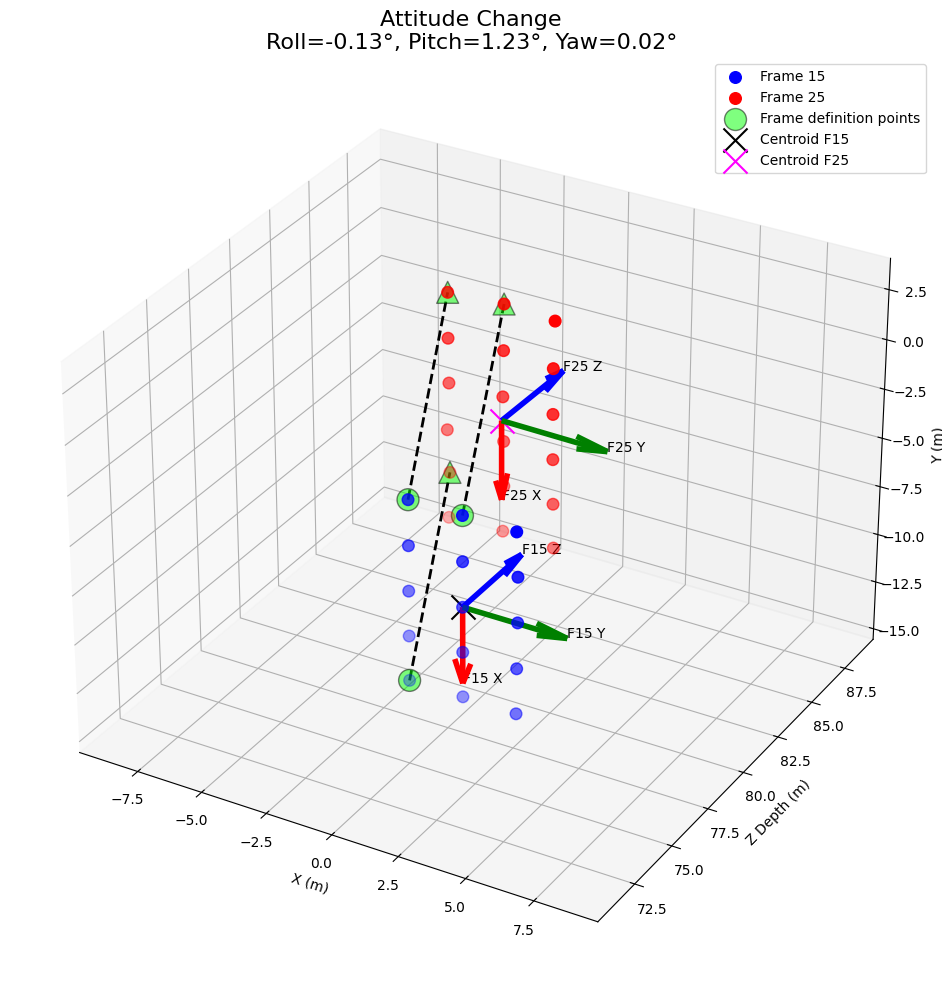

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# ============================================================
# KABSCH / SVD
# ============================================================

def estimate_pose_svd(P, Q):

    centroid_P = np.mean(P, axis=0)
    centroid_Q = np.mean(Q, axis=0)

    P0 = P - centroid_P
    Q0 = Q - centroid_Q

    H = P0.T @ Q0

    U, S, Vt = np.linalg.svd(H)

    R_est = Vt.T @ U.T

    if np.linalg.det(R_est) < 0:
        Vt[-1, :] *= -1
        R_est = Vt.T @ U.T

    t_est = centroid_Q - R_est @ centroid_P

    return R_est, t_est


# ============================================================
# BODY FRAME
# ============================================================

def construct_body_frame(points, idx):

    p1 = points[idx[0]]
    p2 = points[idx[1]]
    p3 = points[idx[2]]

    ex = p2 - p1
    ex /= np.linalg.norm(ex)

    ey_temp = p3 - p1
    ey_temp /= np.linalg.norm(ey_temp)

    ez = np.cross(ex, ey_temp)
    ez /= np.linalg.norm(ez)

    ey = np.cross(ez, ex)
    ey /= np.linalg.norm(ey)

    R_body = np.column_stack([ex, ey, ez])

    return R_body


# ============================================================
# DRAW AXES
# ============================================================

def draw_axes(ax,
              origin,
              R,
              scale=4.0,
              prefix=""):

    colors = ['r', 'g', 'b']
    labels = ['X', 'Y', 'Z']

    for i in range(3):

        axis = R[:, i]

        ax.quiver(
            origin[0],
            origin[2],
            origin[1],

            axis[0] * scale,
            axis[2] * scale,
            axis[1] * scale,

            color=colors[i],
            linewidth=4
        )

        tip = origin + scale * axis

        ax.text(
            tip[0],
            tip[2],
            tip[1],
            f"{prefix}{labels[i]}",
            fontsize=10
        )


# ============================================================
# ATTITUDE ESTIMATION
# ============================================================

N = min(len(P15), len(P25))

P = P15[:N]
Q = P25[:N]

R_est, t_est = estimate_pose_svd(P, Q)

rot = Rotation.from_matrix(R_est)

roll, pitch, yaw = rot.as_euler(
    'xyz',
    degrees=True
)

print("\n=============================")
print("ATTITUDE CHANGE")
print("=============================")
print(f"Roll  : {roll:.4f} deg")
print(f"Pitch : {pitch:.4f} deg")
print(f"Yaw   : {yaw:.4f} deg")

print("\nRotation Matrix")
print(R_est)

print("\nTranslation")
print(t_est)

# ============================================================
# BODY FRAME DEFINITION POINTS
# ============================================================

body_idx = [0, 12, 1]

R15_body = construct_body_frame(
    P15,
    body_idx
)

# Use SVD attitude change
R25_body = R_est @ R15_body

# ============================================================
# CENTROIDS
# ============================================================

centroid15 = np.mean(P15, axis=0)
centroid25 = np.mean(P25, axis=0)

# ============================================================
# SELECTED POINTS
# ============================================================

P_sel = P15[body_idx]
Q_sel = P25[body_idx]

# ============================================================
# PLOT
# ============================================================

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

# ------------------------------------------------------------
# FRAME 15 POINTS
# ------------------------------------------------------------

ax.scatter(
    P15[:,0],
    P15[:,2],
    P15[:,1],
    color='blue',
    s=70,
    label='Frame 15'
)

# ------------------------------------------------------------
# FRAME 25 POINTS
# ------------------------------------------------------------

ax.scatter(
    P25[:,0],
    P25[:,2],
    P25[:,1],
    color='red',
    s=70,
    label='Frame 25'
)

# ------------------------------------------------------------
# SELECTED POINTS
# ------------------------------------------------------------

ax.scatter(
    P_sel[:,0],
    P_sel[:,2],
    P_sel[:,1],
    color='lime',
    s=250,
    alpha=0.5,
    edgecolors='black',
    label='Frame definition points'
)

ax.scatter(
    Q_sel[:,0],
    Q_sel[:,2],
    Q_sel[:,1],
    color='lime',
    marker='^',
    s=250,
    alpha=0.5,
    edgecolors='black'
)

# ------------------------------------------------------------
# CONNECTING LINES
# ------------------------------------------------------------

for i in range(3):

    ax.plot(
        [P_sel[i,0], Q_sel[i,0]],
        [P_sel[i,2], Q_sel[i,2]],
        [P_sel[i,1], Q_sel[i,1]],
        '--k',
        linewidth=2
    )

# ------------------------------------------------------------
# CENTROIDS
# ------------------------------------------------------------

ax.scatter(
    centroid15[0],
    centroid15[2],
    centroid15[1],
    c='black',
    marker='x',
    s=300,
    label='Centroid F15'
)

ax.scatter(
    centroid25[0],
    centroid25[2],
    centroid25[1],
    c='magenta',
    marker='x',
    s=300,
    label='Centroid F25'
)

# ------------------------------------------------------------
# COORDINATE FRAMES
# ------------------------------------------------------------

draw_axes(
    ax,
    centroid15,
    R15_body,
    scale=4.0,
    prefix="F15 "
)

draw_axes(
    ax,
    centroid25,
    R25_body,
    scale=4.0,
    prefix="F25 "
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_title(
    f"Attitude Change\n"
    f"Roll={roll:.2f}°, "
    f"Pitch={pitch:.2f}°, "
    f"Yaw={yaw:.2f}°",
    fontsize=16
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Z Depth (m)")
ax.set_zlabel("Y (m)")

ax.legend()

# ============================================================
# EQUAL SCALE
# ============================================================

all_points = np.vstack([P15, P25])

x_mid = np.mean(all_points[:,0])
y_mid = np.mean(all_points[:,1])
z_mid = np.mean(all_points[:,2])

max_range = np.max(
    np.ptp(all_points, axis=0)
) / 2

ax.set_xlim(
    x_mid - max_range,
    x_mid + max_range
)

ax.set_ylim(
    z_mid - max_range,
    z_mid + max_range
)

ax.set_zlim(
    y_mid - max_range,
    y_mid + max_range
)

plt.tight_layout()
plt.show()